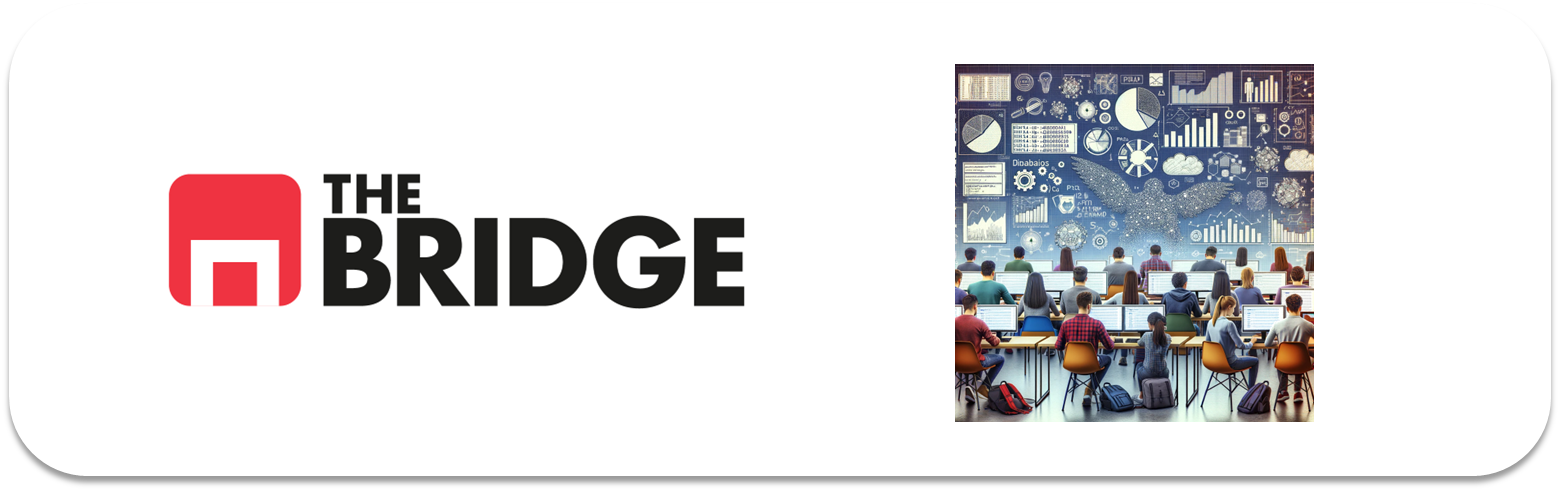

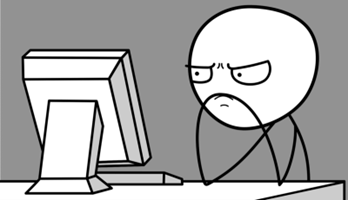

Para ejercitarte y afianzar lo aprendido sobre **Proceso de Datos**, como primera etapa de ML, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


from sklearn.model_selection import train_test_split

### Ejercicio 1

Carga el dataset de advertising que encontrarás en la carpeta de datos. Muestra su información general. ¿Qué te llama la atención? ¿Tendremos que limpiar alguna variable?

In [11]:
df = pd.read_csv('.\\data\\advertising_ml.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   object 
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(2), object(5)
memory usage: 78.3+ KB


In [20]:
df.head(20)

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35 years,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31 years,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26 years,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29 years,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35 años,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0
5,59.99,23 años,59761.56,226.74,Sharable client-driven software,Jamieberg,1,Norway,2016-05-19 14:30:17,0
6,88.91,33 años,53852.85,208.36,Enhanced dedicated support,Brandonstad,0,Myanmar,2016-01-28 20:59:32,0
7,66.00,48 años,24593.33,131.76,Reactive local challenge,Port Jefferybury,1,Australia,2016-03-07 01:40:15,1
8,74.53,30 años,68862.00,221.51,Configurable coherent function,West Colin,1,Grenada,2016-04-18 09:33:42,0
9,69.88,20 años,55642.32,183.82,Mandatory homogeneous architecture,Ramirezton,1,Ghana,2016-07-11 01:42:51,0


### Ejercicio 2

Tenemos que entender el problema antes de seguir. Nos dicen que la compañía "QuickRespond" quiere poder generar un modelo que a partir de datos como los del dataset para poder dirigir mejor su campaña de anuncios. Hablando con ellos llegamos a la conclusión de que queremos un modelo para poder predecir si un usuario pulsará en el link de un anuncio o no. ¿Qué tipo de problemas estamos tratando?¿Y de que tipo de aprendizaje?¿Existe una variable target que puedas identificar rapidamente?

### Ejercicio 3

Volvamos ya a los datos. Intenta dar una definicón de cada columna, obten su cardinalidad y en función de esta y del tipo de variable de pandas, clasifícalas en categóricas y numéricas.

In [13]:
#cardinalidad 
df.nunique()

Daily Time Spent on Site     900
Age                           83
Area Income                 1000
Daily Internet Usage         966
Ad Topic Line               1000
City                         969
Male                           2
Country                      237
Timestamp                   1000
Clicked on Ad                  2
dtype: int64

In [14]:
# Definición básica de columnas
for col in df.columns:
    print(f"{col}: tipo={df[col].dtype}, cardinalidad={df[col].nunique()}")

# Clasificación
numericas = [col for col in df.columns if df[col].dtype in ['float64', 'int64']]
categoricas = [col for col in df.columns if df[col].dtype == 'object']

print("\nVariables numéricas:", numericas)
print("Variables categóricas:", categoricas)


Daily Time Spent on Site: tipo=float64, cardinalidad=900
Age: tipo=object, cardinalidad=83
Area Income: tipo=float64, cardinalidad=1000
Daily Internet Usage: tipo=float64, cardinalidad=966
Ad Topic Line: tipo=object, cardinalidad=1000
City: tipo=object, cardinalidad=969
Male: tipo=int64, cardinalidad=2
Country: tipo=object, cardinalidad=237
Timestamp: tipo=object, cardinalidad=1000
Clicked on Ad: tipo=int64, cardinalidad=2

Variables numéricas: ['Daily Time Spent on Site', 'Area Income', 'Daily Internet Usage', 'Male', 'Clicked on Ad']
Variables categóricas: ['Age', 'Ad Topic Line', 'City', 'Country', 'Timestamp']


### Ejercicio 4

Limpia las columnas que necesiten ser limpiadas, no completes nulos (porque asignar valores a nulos sólo puedes hacerlo primero con el train, ya explicaremos con detalle por qué). 

In [46]:
# Copia de seguridad
df_clean = df.copy()

# 1. Limpieza de nombres de columnas
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

# 2. Detectar columnas con tipo object que deberían ser numéricas
object_cols = df_clean.select_dtypes(include='object').columns
object_cols

Index(['age', 'ad_topic_line', 'city', 'country', 'timestamp'], dtype='object')

In [47]:
#convertir timestamp 
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'], errors='coerce')

In [49]:
#convertir la columna age
df_clean['age'] = (
    df_clean['age']
    .astype(str)
    .str.extract(r'(\d+)')   # extrae el primer grupo de dígitos
    .astype(float)
)

In [51]:
df_clean.info()
df_clean


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   daily_time_spent_on_site  1000 non-null   float64       
 1   age                       1000 non-null   float64       
 2   area_income               1000 non-null   float64       
 3   daily_internet_usage      1000 non-null   float64       
 4   ad_topic_line             1000 non-null   object        
 5   city                      1000 non-null   object        
 6   male                      1000 non-null   int64         
 7   country                   1000 non-null   object        
 8   timestamp                 1000 non-null   datetime64[ns]
 9   clicked_on_ad             1000 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(3)
memory usage: 78.3+ KB


,daily_time_spent_on_site,age,area_income,daily_internet_usage,ad_topic_line,city,male,country,timestamp,clicked_on_ad
0,68.95,35.0,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31.0,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26.0,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29.0,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35.0,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0
...,...,...,...,...,...,...,...,...,...,...
995,72.97,30.0,71384.57,208.58,Fundamental modular algorithm,Duffystad,1,Lebanon,2016-02-11 21:49:00,1
996,51.30,45.0,67782.17,134.42,Grass-roots cohesive monitoring,New Darlene,1,Bosnia and Herzegovina,2016-04-22 02:07:01,1
997,51.63,51.0,42415.72,120.37,Expanded intangible solution,South Jessica,1,Mongolia,2016-02-01 17:24:57,1
998,55.55,19.0,41920.79,187.95,Proactive bandwidth-monitored policy,West Steven,0,Guatemala,2016-03-24 02:35:54,0


### Ejercicio 5

Divide el datset en train y test, empleando sklearn para ello tal y como hemos hecho en el workout. Usa la regla del 80-20

In [53]:
from sklearn.model_selection import train_test_split

# X = variables predictoras
X = df_clean.drop('clicked_on_ad', axis=1)

# y = variable objetivo
y = df_clean['clicked_on_ad']

# División 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,     # 20%
    random_state=42,    # reproducibilidad
    stratify=y          # mantiene proporción de clases
)

### Ejercicio 6

Haz un pequeño análisis univariante de las columnas numéricas (muestra sus histogramas)

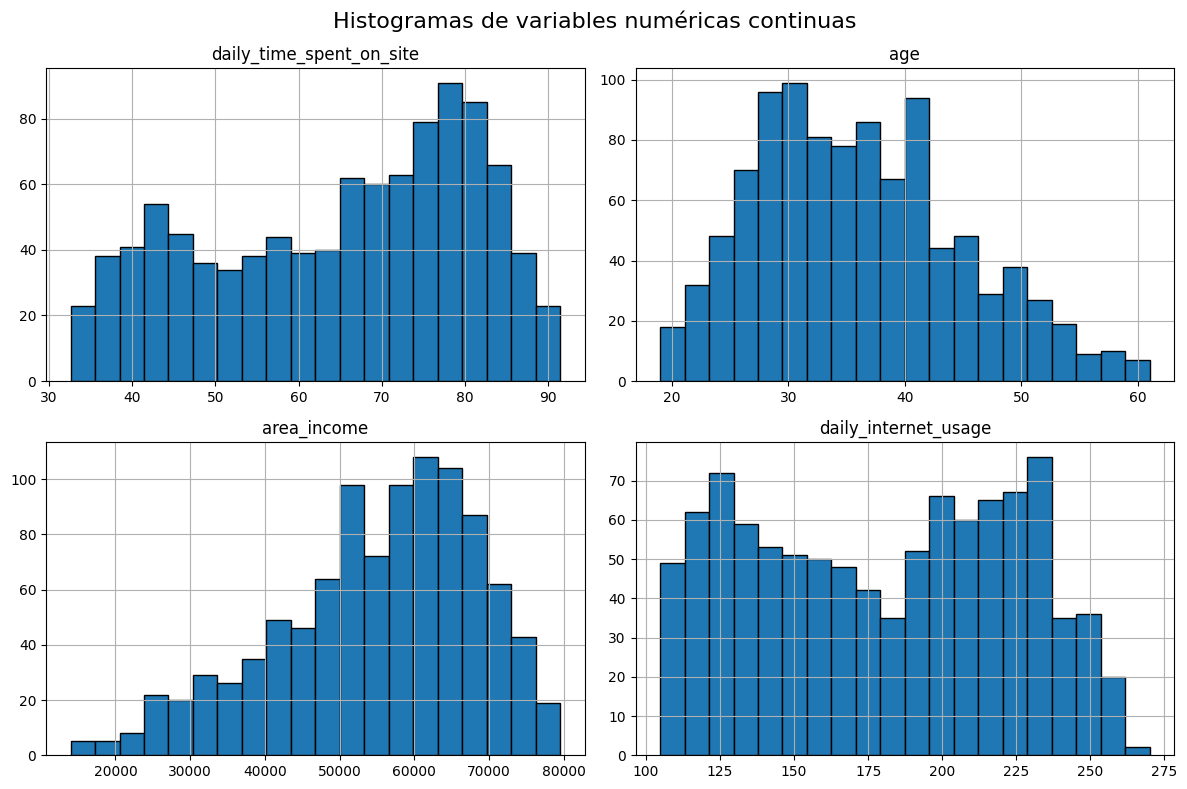

In [55]:
import matplotlib.pyplot as plt

numericas_continuas = [
    'daily_time_spent_on_site',
    'age',
    'area_income',
    'daily_internet_usage'
]

df_clean[numericas_continuas].hist(
    figsize=(12, 8),
    bins=20,
    edgecolor='black'
)

plt.suptitle("Histogramas de variables numéricas continuas", fontsize=16)
plt.tight_layout()
plt.show()

### Ejercicio 7

Muestra las correlaciones de las variables continuas con un "PairPlot" y emplea como codigo de color la variable target. [Esto es otra forma de hacer un bivariante y un multivariante a la vez]. Para ello como argumento del pairplot de seaborn usa el dataframe de train (no la matriz de correlación)

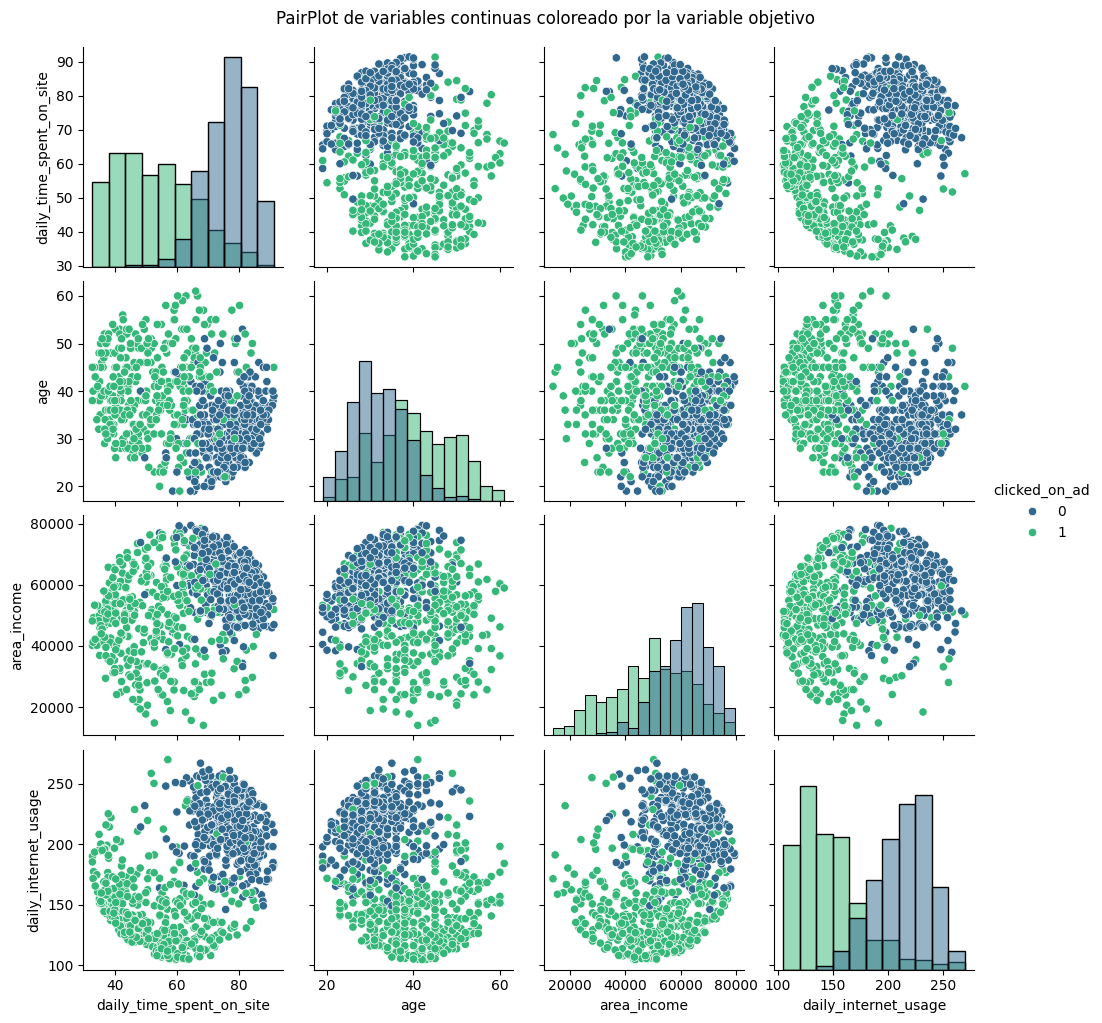

In [56]:
vars_continuas = [
    'daily_time_spent_on_site',
    'age',
    'area_income',
    'daily_internet_usage'
]

# Unimos X_train e y_train para poder usar hue
train_df = X_train.copy()
train_df['clicked_on_ad'] = y_train

sns.pairplot(
    train_df,
    vars=vars_continuas,
    hue='clicked_on_ad',
    diag_kind='hist',
    palette='viridis'
)

plt.suptitle("PairPlot de variables continuas coloreado por la variable objetivo", y=1.02)
plt.show()

### Ejercicio 8

Fijándote en la diagonal principal del gráfico anterior haz una selecció de features:

In [57]:
features_seleccionadas = [
    'daily_time_spent_on_site',
    'age',
    'area_income',
    'daily_internet_usage'
]

features_seleccionadas += ['male']
